In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Configuration pour les graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Charger les données
df = pd.read_csv('Air_quality_kampala_cleaned_final.csv')

# Convertir la colonne timestamp en datetime
df['timestamp_round'] = pd.to_datetime(df['timestamp_round'])

# Afficher les premières lignes et informations sur le dataset
print("Aperçu des données:")
print(df.head())
print(f"\nDimensions du dataset: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nPériode des données: {df['timestamp_round'].min()} à {df['timestamp_round'].max()}")
print(f"\nNombre de capteurs: {df['sensor_id'].nunique()}")

Aperçu des données:
   sensor_id    lat     lon     timestamp_round   PM10   PM25  humidity  temp
0         42  0.323  32.576 2018-03-01 00:02:00  22.30  14.20      61.1  25.2
1         42  0.323  32.576 2018-03-01 00:04:00  20.07  14.07      61.2  25.2
2         42  0.323  32.576 2018-03-01 00:07:00  25.60  15.27      61.3  25.3
3         42  0.323  32.576 2018-03-01 00:09:00  28.75  16.77      61.3  25.2
4         42  0.323  32.576 2018-03-01 00:12:00  25.23  15.37      61.4  25.2

Dimensions du dataset: (9499, 8)

Colonnes: ['sensor_id', 'lat', 'lon', 'timestamp_round', 'PM10', 'PM25', 'humidity', 'temp']

Période des données: 2018-03-01 00:02:00 à 2018-03-21 13:00:00

Nombre de capteurs: 1


In [20]:
# Statistiques descriptives
print("Statistiques descriptives des variables numériques:")
print(df.describe())

# Vérification des valeurs manquantes
print(f"\nValeurs manquantes par colonne:")
print(df.isnull().sum())

Statistiques descriptives des variables numériques:
       sensor_id           lat       lon             timestamp_round  \
count     9499.0  9.499000e+03  9499.000                        9499   
mean        42.0  3.230000e-01    32.576  2018-03-10 05:01:55.458469   
min         42.0  3.230000e-01    32.576         2018-03-01 00:02:00   
25%         42.0  3.230000e-01    32.576         2018-03-05 04:38:30   
50%         42.0  3.230000e-01    32.576         2018-03-09 11:44:00   
75%         42.0  3.230000e-01    32.576         2018-03-15 13:24:00   
max         42.0  3.230000e-01    32.576         2018-03-21 13:00:00   
std          0.0  5.551407e-17     0.000                         NaN   

              PM10         PM25    humidity         temp  
count  9499.000000  9499.000000  9499.00000  9499.000000  
mean     25.266393    13.132321    68.78464    24.556532  
min       1.900000     1.700000    42.60000    20.100000  
25%      11.870000     6.230000    63.90000    23.300000  
50% 

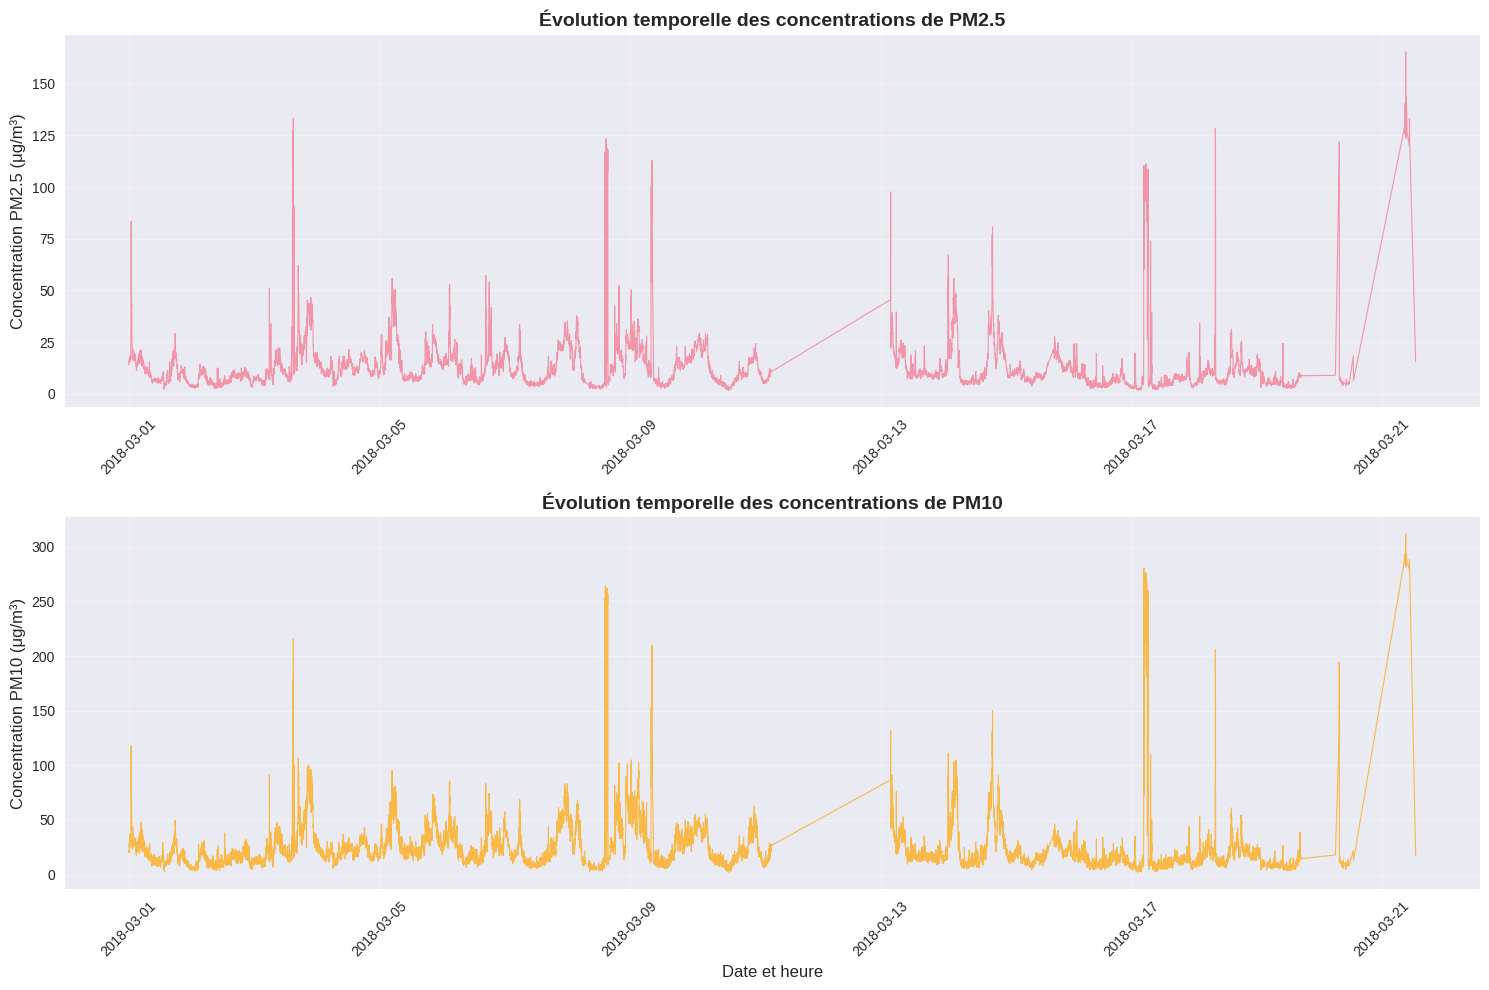

In [21]:
# Visualisation des séries temporelles pour PM2.5 et PM10
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# PM2.5
axes[0].plot(df['timestamp_round'], df['PM25'], alpha=0.7, linewidth=0.8)
axes[0].set_title('Évolution temporelle des concentrations de PM2.5', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Concentration PM2.5 (μg/m³)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# PM10
axes[1].plot(df['timestamp_round'], df['PM10'], alpha=0.7, linewidth=0.8, color='orange')
axes[1].set_title('Évolution temporelle des concentrations de PM10', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Concentration PM10 (μg/m³)', fontsize=12)
axes[1].set_xlabel('Date et heure', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

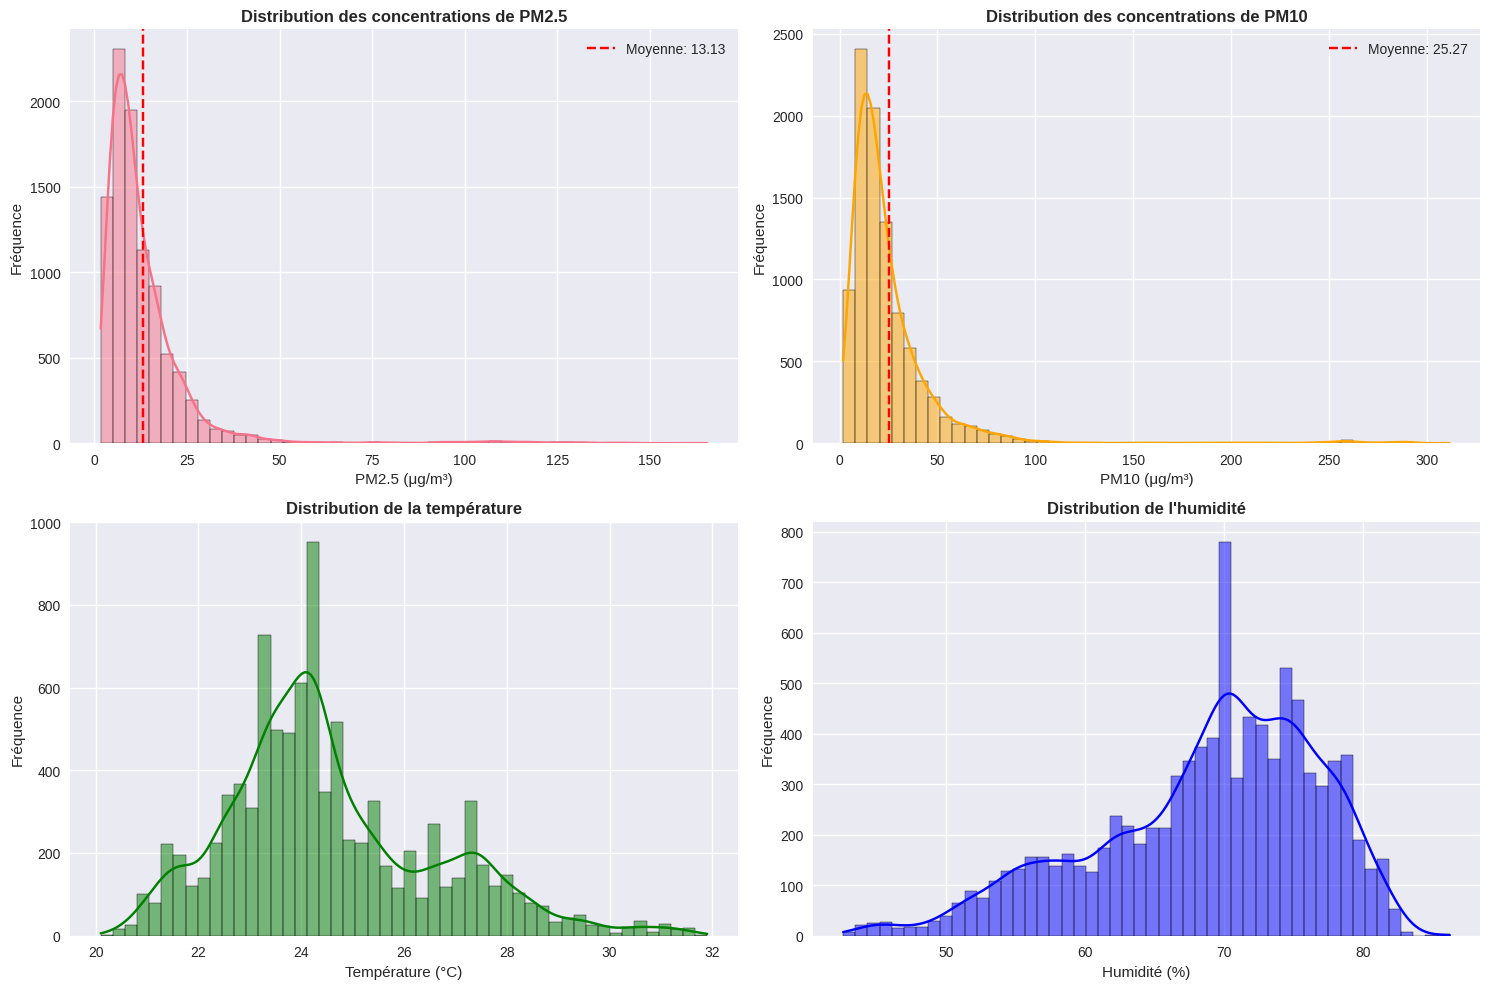

In [22]:
# Distribution des polluants et conditions météorologiques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution PM2.5
sns.histplot(df['PM25'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution des concentrations de PM2.5', fontweight='bold')
axes[0,0].set_xlabel('PM2.5 (μg/m³)')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].axvline(df['PM25'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["PM25"].mean():.2f}')
axes[0,0].legend()

# Distribution PM10
sns.histplot(df['PM10'], bins=50, kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribution des concentrations de PM10', fontweight='bold')
axes[0,1].set_xlabel('PM10 (μg/m³)')
axes[0,1].set_ylabel('Fréquence')
axes[0,1].axvline(df['PM10'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["PM10"].mean():.2f}')
axes[0,1].legend()

# Distribution Température
sns.histplot(df['temp'], bins=50, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Distribution de la température', fontweight='bold')
axes[1,0].set_xlabel('Température (°C)')
axes[1,0].set_ylabel('Fréquence')

# Distribution Humidité
sns.histplot(df['humidity'], bins=50, kde=True, ax=axes[1,1], color='blue')
axes[1,1].set_title('Distribution de l\'humidité', fontweight='bold')
axes[1,1].set_xlabel('Humidité (%)')
axes[1,1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

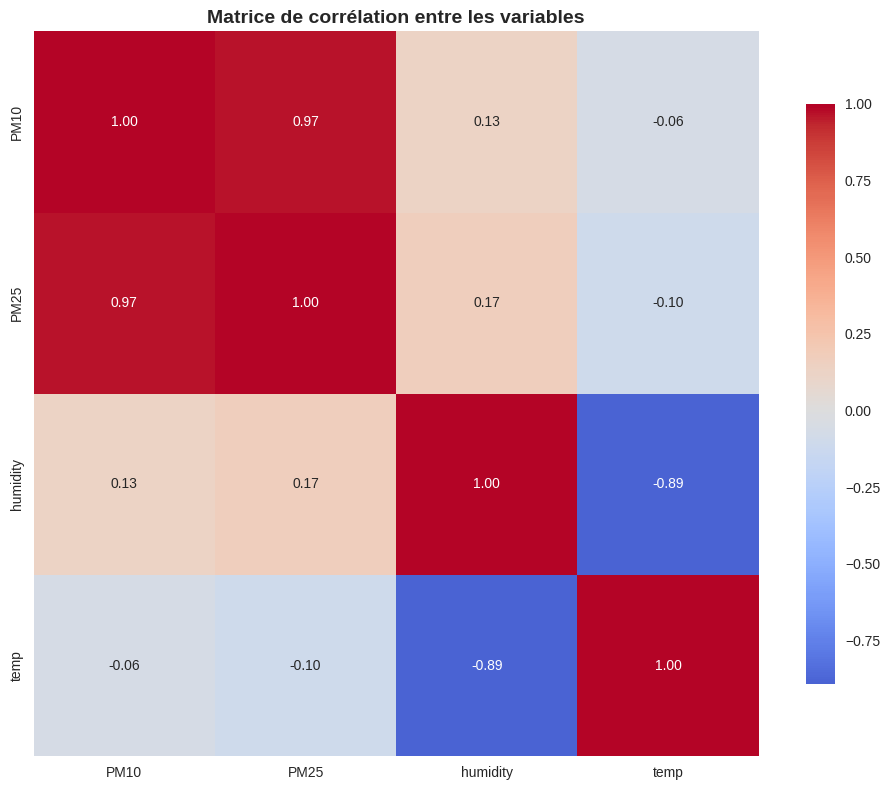

Corrélations les plus fortes:
PM10      PM25        0.967445
PM25      PM10        0.967445
humidity  temp        0.890929
temp      humidity    0.890929
PM25      humidity    0.169433
dtype: float64


In [23]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = df[['PM10', 'PM25', 'humidity', 'temp']].corr()

# Créer une heatmap avec annotations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matrice de corrélation entre les variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Afficher les corrélations les plus fortes
print("Corrélations les plus fortes:")
correlations = correlation_matrix.unstack()
correlations = correlations[correlations != 1.0]  # Exclure les autocorrélations
correlations = correlations.abs().sort_values(ascending=False)
print(correlations.head())

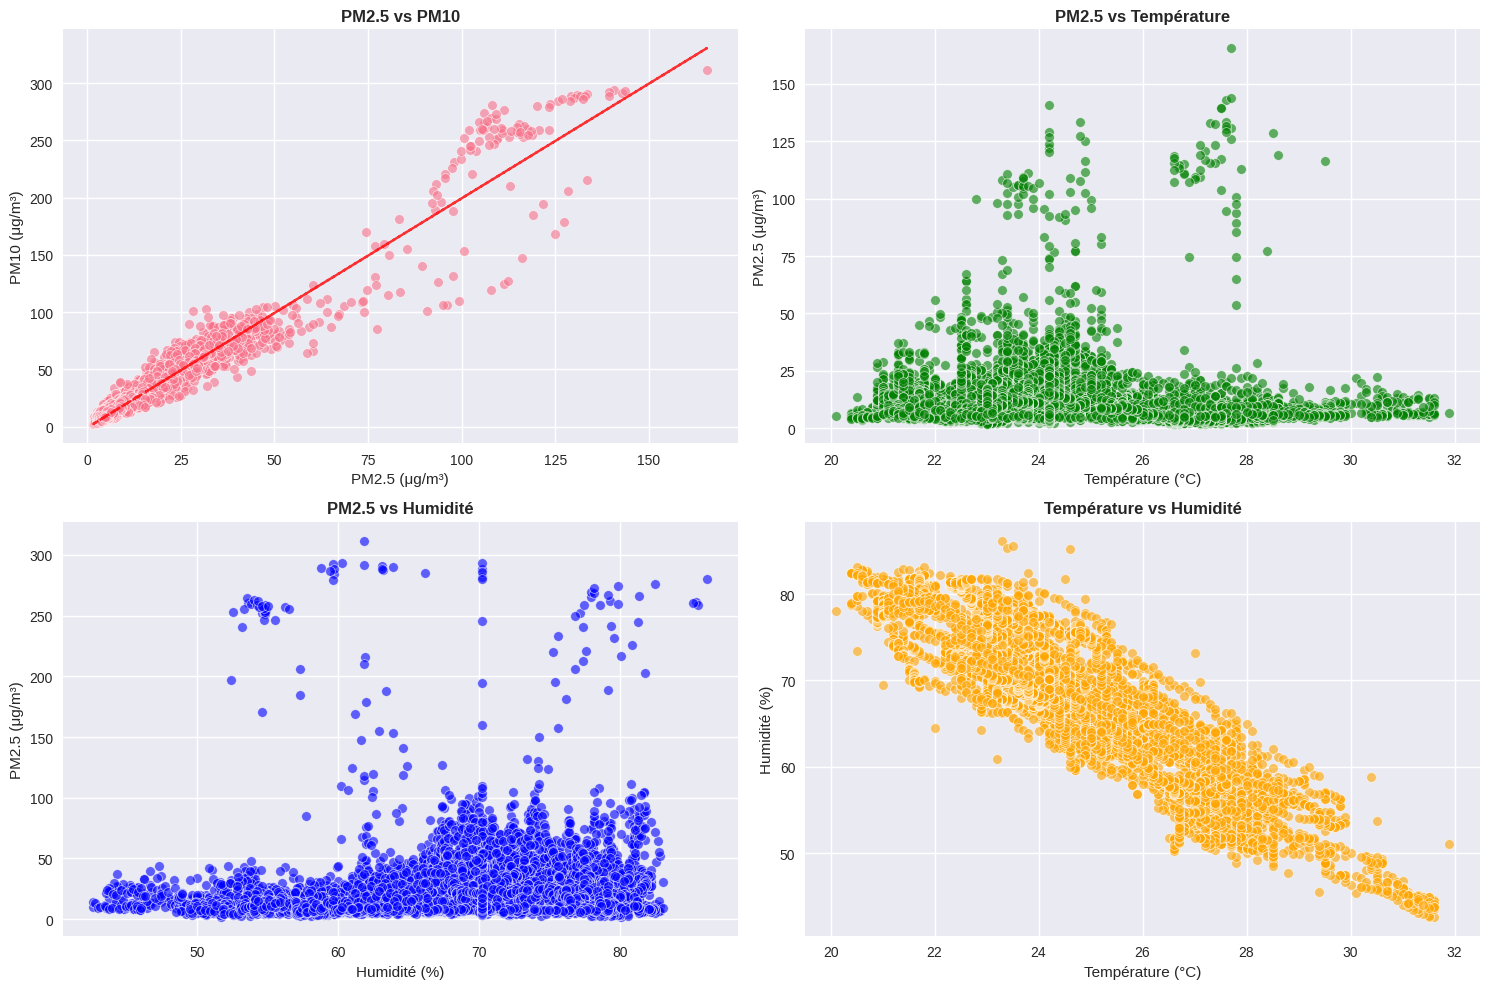

In [ ]:
# Nuages de points pour explorer les relations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PM2.5 vs PM10
sns.scatterplot(data=df, x='PM25', y='PM10', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('PM2.5 vs PM10', fontweight='bold')
axes[0,0].set_xlabel('PM2.5 (μg/m³)')
axes[0,0].set_ylabel('PM10 (μg/m³)')
# Ajouter ligne de tendance
z = np.polyfit(df['PM25'], df['PM10'], 1)
p = np.poly1d(z)
axes[0,0].plot(df['PM25'], p(df['PM25']), "r--", alpha=0.8)

# PM2.5 vs Température
sns.scatterplot(data=df, x='temp', y='PM25', alpha=0.6, ax=axes[0,1], color='green')
axes[0,1].set_title('PM2.5 vs Température', fontweight='bold')
axes[0,1].set_xlabel('Température (°C)')
axes[0,1].set_ylabel('PM2.5 (μg/m³)')

# PM2.5 vs Humidité
sns.scatterplot(data=df, x='humidity', y='PM25', alpha=0.6, ax=axes[1,0], color='blue')
axes[1,0].set_title('PM2.5 vs Humidité', fontweight='bold')
axes[1,0].set_xlabel('Humidité (%)')
axes[1,0].set_ylabel('PM2.5 (μg/m³)')



# Température vs Humidité
sns.scatterplot(data=df, x='temp', y='humidity', alpha=0.6, ax=axes[1,1], color='orange')
axes[1,1].set_title('Température vs Humidité', fontweight='bold')
axes[1,1].set_xlabel('Température (°C)')
axes[1,1].set_ylabel('Humidité (%)')

plt.tight_layout()
plt.show()

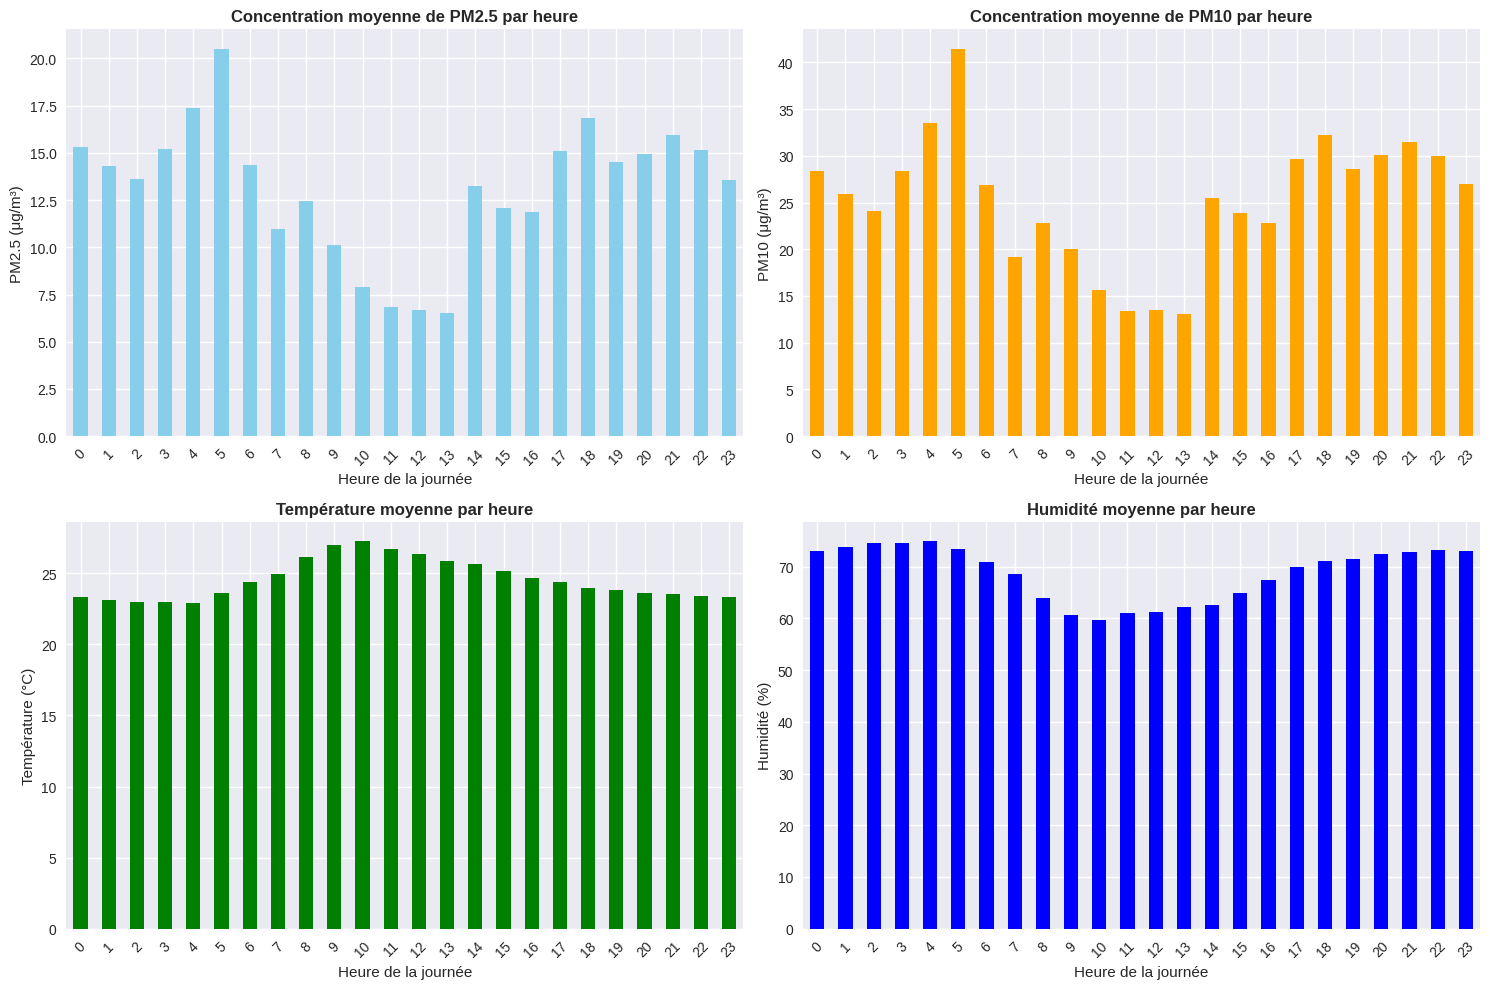

In [25]:
# Analyse par heure de la journée
df['hour'] = df['timestamp_round'].dt.hour
df['date'] = df['timestamp_round'].dt.date

# Moyennes par heure
hourly_avg = df.groupby('hour')[['PM25', 'PM10', 'temp', 'humidity']].mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PM2.5 par heure
hourly_avg['PM25'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Concentration moyenne de PM2.5 par heure', fontweight='bold')
axes[0,0].set_xlabel('Heure de la journée')
axes[0,0].set_ylabel('PM2.5 (μg/m³)')
axes[0,0].tick_params(axis='x', rotation=45)

# PM10 par heure
hourly_avg['PM10'].plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Concentration moyenne de PM10 par heure', fontweight='bold')
axes[0,1].set_xlabel('Heure de la journée')
axes[0,1].set_ylabel('PM10 (μg/m³)')
axes[0,1].tick_params(axis='x', rotation=45)

# Température par heure
hourly_avg['temp'].plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Température moyenne par heure', fontweight='bold')
axes[1,0].set_xlabel('Heure de la journée')
axes[1,0].set_ylabel('Température (°C)')
axes[1,0].tick_params(axis='x', rotation=45)

# Humidité par heure
hourly_avg['humidity'].plot(kind='bar', ax=axes[1,1], color='blue')
axes[1,1].set_title('Humidité moyenne par heure', fontweight='bold')
axes[1,1].set_xlabel('Heure de la journée')
axes[1,1].set_ylabel('Humidité (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

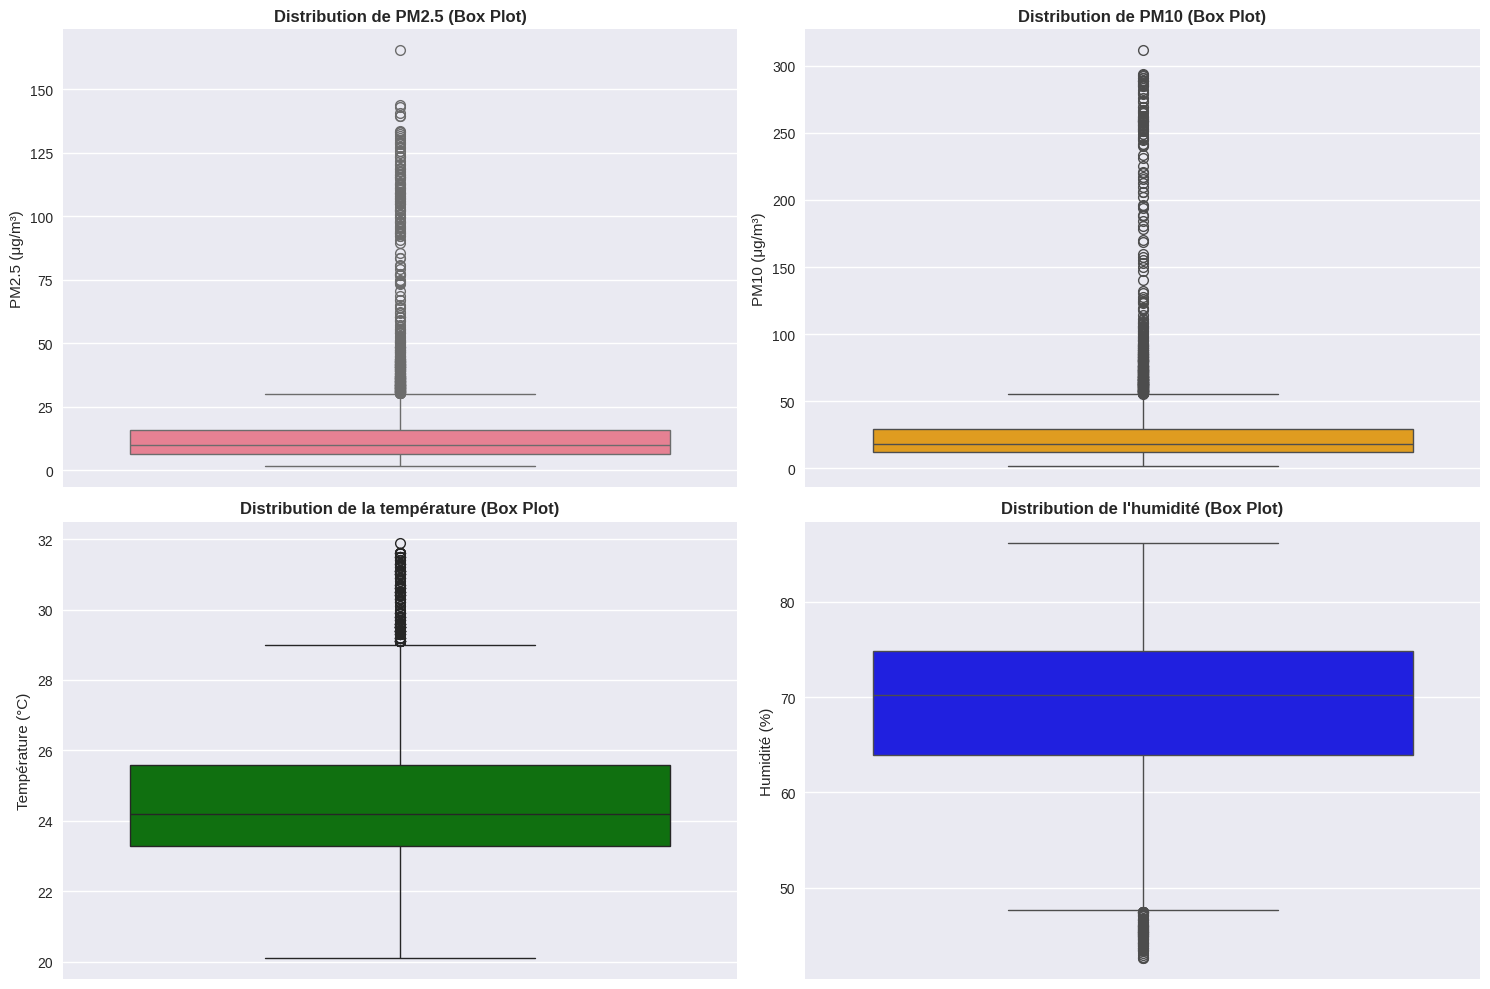

Analyse des outliers:
PM25: 461 outliers (4.9% des données)
PM10: 601 outliers (6.3% des données)
temp: 276 outliers (2.9% des données)
humidity: 112 outliers (1.2% des données)


In [26]:
# Box plots pour visualiser la distribution et les outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Box plot PM2.5
sns.boxplot(y=df['PM25'], ax=axes[0,0])
axes[0,0].set_title('Distribution de PM2.5 (Box Plot)', fontweight='bold')
axes[0,0].set_ylabel('PM2.5 (μg/m³)')

# Box plot PM10
sns.boxplot(y=df['PM10'], ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribution de PM10 (Box Plot)', fontweight='bold')
axes[0,1].set_ylabel('PM10 (μg/m³)')

# Box plot Température
sns.boxplot(y=df['temp'], ax=axes[1,0], color='green')
axes[1,0].set_title('Distribution de la température (Box Plot)', fontweight='bold')
axes[1,0].set_ylabel('Température (°C)')

# Box plot Humidité
sns.boxplot(y=df['humidity'], ax=axes[1,1], color='blue')
axes[1,1].set_title('Distribution de l\'humidité (Box Plot)', fontweight='bold')
axes[1,1].set_ylabel('Humidité (%)')

plt.tight_layout()
plt.show()

# Statistiques sur les outliers
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

print("Analyse des outliers:")
for col in ['PM25', 'PM10', 'temp', 'humidity']:
    outliers = detect_outliers_iqr(df[col])
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}% des données)")

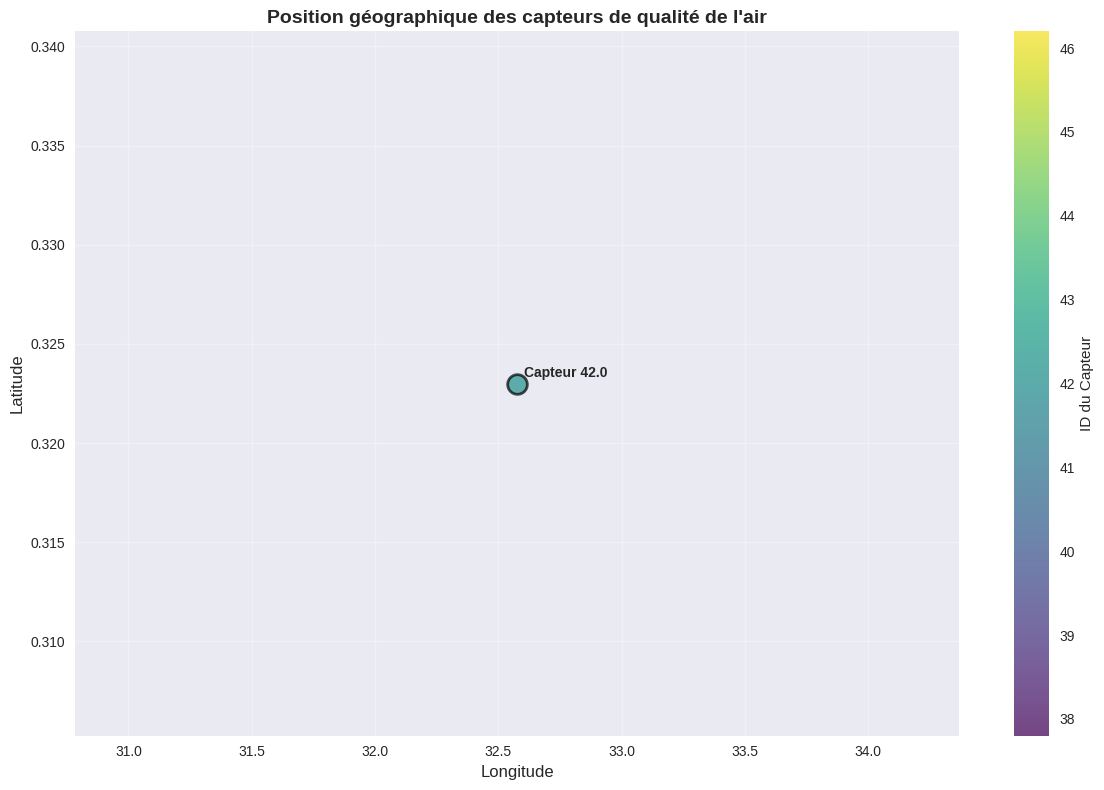

Positions des capteurs:
   sensor_id    lat     lon
0         42  0.323  32.576


In [27]:
# Visualisation géographique des capteurs
plt.figure(figsize=(12, 8))

# Obtenir les positions uniques des capteurs
sensor_locations = df.groupby('sensor_id')[['lat', 'lon']].first().reset_index()

# Créer un scatter plot des positions des capteurs
scatter = plt.scatter(sensor_locations['lon'], sensor_locations['lat'], 
                     s=200, c=sensor_locations['sensor_id'], cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=2)

# Ajouter les labels des capteurs
for idx, row in sensor_locations.iterrows():
    plt.annotate(f'Capteur {row["sensor_id"]}', 
                (row['lon'], row['lat']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.colorbar(scatter, label='ID du Capteur')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Position géographique des capteurs de qualité de l\'air', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Positions des capteurs:")
print(sensor_locations)

In [30]:
# ANALYSE D'OPTIMISATION - PLACEMENT STRATÉGIQUE DE CAPTEURS
print("="*80)
print("PROBLÈME D'OPTIMISATION: Placement optimal de capteurs pour la surveillance des PM2.5")
print("="*80)

# Analyse préliminaire des données actuelles
print("\n1. ANALYSE DES DONNÉES ACTUELLES:")
print(f"   - Nombre total de mesures: {len(df):,}")
print(f"   - Nombre de capteurs existants: {df['sensor_id'].nunique()}")
print(f"   - Période de couverture: {(df['timestamp_round'].max() - df['timestamp_round'].min()).days} jours")
print(f"   - Fréquence d'échantillonnage moyenne: {len(df) / df['sensor_id'].nunique():.1f} mesures par capteur")

# Statistiques spatiales
sensor_locations = df.groupby('sensor_id')[['lat', 'lon']].first()
print(f"   - Zone géographique couverte:")
print(f"     * Latitude: {sensor_locations['lat'].min():.3f} à {sensor_locations['lat'].max():.3f}")
print(f"     * Longitude: {sensor_locations['lon'].min():.3f} à {sensor_locations['lon'].max():.3f}")

# Variabilité spatiale des PM2.5
pm25_stats_by_sensor = df.groupby('sensor_id')['PM25'].agg(['mean', 'std', 'min', 'max'])
print(f"\n2. VARIABILITÉ SPATIALE DES PM2.5:")
print(f"   - Moyenne globale: {df['PM25'].mean():.2f} μg/m³")
print(f"   - Écart-type global: {df['PM25'].std():.2f} μg/m³")
print(f"   - Variation entre capteurs: {pm25_stats_by_sensor['mean'].std():.2f} μg/m³")
print(f"   - Plage de moyennes par capteur: {pm25_stats_by_sensor['mean'].min():.2f} - {pm25_stats_by_sensor['mean'].max():.2f} μg/m³")

PROBLÈME D'OPTIMISATION: Placement optimal de capteurs pour la surveillance des PM2.5

1. ANALYSE DES DONNÉES ACTUELLES:
   - Nombre total de mesures: 9,499
   - Nombre de capteurs existants: 1
   - Période de couverture: 20 jours
   - Fréquence d'échantillonnage moyenne: 9499.0 mesures par capteur
   - Zone géographique couverte:
     * Latitude: 0.323 à 0.323
     * Longitude: 32.576 à 32.576

2. VARIABILITÉ SPATIALE DES PM2.5:
   - Moyenne globale: 13.13 μg/m³
   - Écart-type global: 13.36 μg/m³
   - Variation entre capteurs: nan μg/m³
   - Plage de moyennes par capteur: 13.13 - 13.13 μg/m³


In [31]:
# 3. APPROCHES D'OPTIMISATION POSSIBLES
print("\n3. APPROCHES D'OPTIMISATION POSSIBLES:")
print("\n   A. OPTIMISATION COMBINATOIRE:")
print("      - Problème de sélection d'emplacements (Facility Location Problem)")
print("      - Maximiser la couverture spatiale avec K capteurs")
print("      - Minimiser la redondance entre capteurs voisins")
print("\n   B. APPROCHE STATISTIQUE:")
print("      - Krigeage (Gaussian Process Regression)")
print("      - Interpolation spatiale optimisée")
print("      - Validation croisée pour évaluer la performance")
print("\n   C. APPRENTISSAGE AUTOMATIQUE:")
print("      - Features engineering: distance, densité, météo")
print("      - Modèles d'ensemble (Random Forest, Gradient Boosting)")
print("      - Deep Learning pour la reconstruction spatiale")

# Calcul de métriques pour l'optimisation
print("\n4. MÉTRiques D'ÉVALUATION:")
print("   - RMSE (Root Mean Square Error) entre valeurs prédites et réelles")
print("   - MAE (Mean Absolute Error)")
print("   - R² (Coefficient de détermination)")
print("   - Couverture spatiale (% de zone surveillée")
print("   - Coût par unité d'information")


3. APPROCHES D'OPTIMISATION POSSIBLES:

   A. OPTIMISATION COMBINATOIRE:
      - Problème de sélection d'emplacements (Facility Location Problem)
      - Maximiser la couverture spatiale avec K capteurs
      - Minimiser la redondance entre capteurs voisins

   B. APPROCHE STATISTIQUE:
      - Krigeage (Gaussian Process Regression)
      - Interpolation spatiale optimisée
      - Validation croisée pour évaluer la performance

   C. APPRENTISSAGE AUTOMATIQUE:
      - Features engineering: distance, densité, météo
      - Modèles d'ensemble (Random Forest, Gradient Boosting)
      - Deep Learning pour la reconstruction spatiale

4. MÉTRiques D'ÉVALUATION:
   - RMSE (Root Mean Square Error) entre valeurs prédites et réelles
   - MAE (Mean Absolute Error)
   - R² (Coefficient de détermination)
   - Couverture spatiale (% de zone surveillée
   - Coût par unité d'information


In [33]:
# 5. DÉFINITION FORMELLE DU PROBLÈME D'OPTIMISATION
import numpy as np
from scipy.spatial.distance import cdist

print("\n5. FORMULATION MATHÉMATIQUE:")
print("\n   Variables:")
print("   - x_i ∈ {0,1}: 1 si capteur i est placé, 0 sinon")
print("   - K: nombre total de capteurs disponibles (contrainte budgétaire)")
print("   - d_ij: distance entre emplacement i et j")
print("   - w_i: poids/importance de l'emplacement i")

print("\n   Objectif:")
print("   Maximiser Σ_i w_i * x_i - λ * Σ_i Σ_j x_i * x_j * f(d_ij)")
print("   où:")
print("   - Premier terme: couverture des zones importantes")
print("   - Second terme: pénalité pour la redondance")
print("   - λ: paramètre de régularisation")
print("   - f(d_ij): fonction décroissante de la distance")

print("\n   Contraintes:")
print("   - Σ_i x_i ≤ K (limite budgétaire)")
print("   - x_i ∈ {0,1} (décision binaire)")

# Analyse des distances actuelles
locations = sensor_locations[['lat', 'lon']].values
distances = cdist(locations, locations)
np.fill_diagonal(distances, np.inf)  # Ignorer les distances à soi-même

print(f"\n6. ANALYSE DES DISTANCES ACTUELLES ENTRE CAPTEURS:")
print(f"   - Distance minimale: {distances.min():.4f} degrés")
print(f"   - Distance maximale: {distances.max():.4f} degrés")
print(f"   - Distance moyenne: {distances.mean():.4f} degrés")


5. FORMULATION MATHÉMATIQUE:

   Variables:
   - x_i ∈ {0,1}: 1 si capteur i est placé, 0 sinon
   - K: nombre total de capteurs disponibles (contrainte budgétaire)
   - d_ij: distance entre emplacement i et j
   - w_i: poids/importance de l'emplacement i

   Objectif:
   Maximiser Σ_i w_i * x_i - λ * Σ_i Σ_j x_i * x_j * f(d_ij)
   où:
   - Premier terme: couverture des zones importantes
   - Second terme: pénalité pour la redondance
   - λ: paramètre de régularisation
   - f(d_ij): fonction décroissante de la distance

   Contraintes:
   - Σ_i x_i ≤ K (limite budgétaire)
   - x_i ∈ {0,1} (décision binaire)

6. ANALYSE DES DISTANCES ACTUELLES ENTRE CAPTEURS:
   - Distance minimale: inf degrés
   - Distance maximale: inf degrés
   - Distance moyenne: inf degrés


In [34]:
# 7. STRATÉGIES DE RÉSOLUTION
print("\n7. STRATÉGIES DE RÉSOLUTION:")

print("\n   A. MÉTHODES EXACTES (pour petits problèmes):")
print("      - Programmation linéaire en nombres entiers (MILP)")
print("      - Branch and Bound")
print("      - Complexité: O(2^n) - seulement pour n < 20")

print("\n   B. HEURISTIQUES ET MÉTAHEURISTIQUES:")
print("      - Algorithme glouton (Greedy)")
print("      - Recuit simulé (Simulated Annealing)")
print("      - Recherche tabou (Tabu Search)")
print("      - Algorithmes génétiques")
print("      - Complexité: acceptable pour n > 100")

print("\n   C. APPROCHES PROBABILISTES:")
print("      - Échantillonnage de Monte Carlo")
print("      - Processus gaussiens pour la modélisation")
print("      - Méthodes bayésiennes")

# Implémentation simple d'un algorithme glouton
def greedy_sensor_placement(df, k_sensors, weight_col='PM25'):
    """
    Algorithme glouton pour le placement de capteurs
    """
    # Calculer les poids basés sur la variabilité des PM2.5
    weights = df.groupby(['lat', 'lon'])[weight_col].std().reset_index()
    weights.columns = ['lat', 'lon', 'weight']
    
    # Normaliser les poids
    weights['weight'] = (weights['weight'] - weights['weight'].min()) / (weights['weight'].max() - weights['weight'].min())
    
    # Sélection gloutonne
    selected = []
    remaining = weights.copy()
    
    for _ in range(min(k_sensors, len(remaining))):
        if len(remaining) == 0:
            break
            
        # Choisir l'emplacement avec le poids maximal
        best_idx = remaining['weight'].idxmax()
        best_location = remaining.loc[best_idx]
        selected.append(best_location[['lat', 'lon']].tolist())
        
        # Retirer les emplacements trop proches
        if len(selected) > 1:
            distances = cdist([best_location[['lat', 'lon']].values], 
                            remaining[['lat', 'lon']].values)[0]
            remaining = remaining[distances > 0.01]  # Seuil de distance minimal
        
        remaining = remaining.drop(best_idx)
    
    return selected

print("\n   D. IMPLÉMENTATION GLoutONNE:")
print("      - Complexité: O(n²)")
print("      - Garantie: solution dans un facteur log(n) de l'optimal")
print("      - Rapide et facile à implémenter")


7. STRATÉGIES DE RÉSOLUTION:

   A. MÉTHODES EXACTES (pour petits problèmes):
      - Programmation linéaire en nombres entiers (MILP)
      - Branch and Bound
      - Complexité: O(2^n) - seulement pour n < 20

   B. HEURISTIQUES ET MÉTAHEURISTIQUES:
      - Algorithme glouton (Greedy)
      - Recuit simulé (Simulated Annealing)
      - Recherche tabou (Tabu Search)
      - Algorithmes génétiques
      - Complexité: acceptable pour n > 100

   C. APPROCHES PROBABILISTES:
      - Échantillonnage de Monte Carlo
      - Processus gaussiens pour la modélisation
      - Méthodes bayésiennes

   D. IMPLÉMENTATION GLoutONNE:
      - Complexité: O(n²)
      - Garantie: solution dans un facteur log(n) de l'optimal
      - Rapide et facile à implémenter


In [ ]:
# 8. SIMULATION DE DIFFÉRENTS SCÉNARIOS DE PLACEMENT
print("\n8. SIMULATION DE SCÉNARIOS:")

# Scénarios de nombre de capteurs
scenarios = [1, 2, 3, 5, 10, 15]

for k in scenarios:
    selected_locations = greedy_sensor_placement(df, k)
    print(f"\n   Scénario {k} capteurs:")
    print(f"   - Emplacements sélectionnés: {len(selected_locations)}")
    for i, loc in enumerate(selected_locations):
        print(f"     Capteur {i+1}: ({loc[0]:.3f}, {loc[1]:.3f})")

print("\n9. FACTEURS À CONSIDÉRER POUR L'OPTIMISATION:")
print("\n   A. FACTEURS ENVIRONNEMENTAUX:")
print("      - Sources de pollution (industries, routes)")
print("      - Conditions météorologiques dominantes")
print("      - Topographie locale")
print("      - Densité de population")

print("\n   B. FACTEURS TECHNIQUES:")
print("      - Portée et précision des capteurs")
print("      - Maintenance et calibration")
print("      - Connectivité réseau")
print("      - Alimentation électrique")

print("\n   C. FACTEURS ÉCONOMIQUES:")
print("      - Coût d'installation par capteur")
print("      - Coût de maintenance annuel")
print("      - Budget total disponible")
print("      - Retour sur investissement")


8. SIMULATION DE SCÉNARIOS:


ValueError: Encountered all NA values

In [37]:
# 10. PROCHAINES ÉTAPES RECOMMANDÉES
print("\n10. PROCHAINES ÉTAPES RECOMMANDÉES:")

print("\n   ÉTAPE 1: ANALYSE EXPLORATOIRE AVANCÉE")
print("   - Cartographie de la densité de population")
print("   - Identification des points chauds de pollution")
print("   - Analyse des corrélations spatio-temporelles")

print("\n   ÉTAPE 2: MODÉLISATION PRÉDICTIVE")
print("   - Développer un modèle de krigeage")
print("   - Validation croisée leave-one-out")
print("   - Quantification de l'incertitude")

print("\n   ÉTAPE 3: OPTIMISATION MULTI-OBJECTIFS")
print("   - Minimiser l'erreur de prédiction")
print("   - Maximiser la couverture population")
print("   - Minimiser le coût total")

print("\n   ÉTAPE 4: SIMULATION ET VALIDATION")
print("   - Tests sur différents scénarios")
print("   - Analyse de sensibilité")
print("   - Robustesse aux pannes de capteurs")

print("\n   ÉTAPE 5: DÉPLOIEMENT PILOTE")
print("   - Installation sur un sous-ensemble de sites")
print("   - Monitoring en temps réel")
print("   - Ajustement itératif du modèle")

print("\n" + "="*80)
print("RÉSUMÉ DES ORIENTATIONS STRATÉGIQUES")
print("="*80)
print("\n1. APPROCHE HYBRIDE: Combiner optimisation combinatoire + ML")
print("2. MÉTHODOLOGIE: Glouton → Validation → Amélioration itérative")
print("3. VALIDATION: Cross-validation + métriques d'incertitude")
print("4. DÉPLOIEMENT: Progressif avec monitoring continu")
print("5. OBJECTIF: Carte fiable avec coût minimal")
print("="*80)


10. PROCHAINES ÉTAPES RECOMMANDÉES:

   ÉTAPE 1: ANALYSE EXPLORATOIRE AVANCÉE
   - Cartographie de la densité de population
   - Identification des points chauds de pollution
   - Analyse des corrélations spatio-temporelles

   ÉTAPE 2: MODÉLISATION PRÉDICTIVE
   - Développer un modèle de krigeage
   - Validation croisée leave-one-out
   - Quantification de l'incertitude

   ÉTAPE 3: OPTIMISATION MULTI-OBJECTIFS
   - Minimiser l'erreur de prédiction
   - Maximiser la couverture population
   - Minimiser le coût total

   ÉTAPE 4: SIMULATION ET VALIDATION
   - Tests sur différents scénarios
   - Analyse de sensibilité
   - Robustesse aux pannes de capteurs

   ÉTAPE 5: DÉPLOIEMENT PILOTE
   - Installation sur un sous-ensemble de sites
   - Monitoring en temps réel
   - Ajustement itératif du modèle

RÉSUMÉ DES ORIENTATIONS STRATÉGIQUES

1. APPROCHE HYBRIDE: Combiner optimisation combinatoire + ML
2. MÉTHODOLOGIE: Glouton → Validation → Amélioration itérative
3. VALIDATION: Cross-valida